# Lab 1: The Apollo Missions

## Introduction
------

Imagine you are an engineer working on the very early days of the Apollo program. In order to
send people to the moon, you need a basic understanding of the gravitational potential and forces
the mission will experience. You also need to start quantifying the performance of the new rocket
that will carry the capsule: the Saturn V.

Your team at NASA has been tasked with conducting a series of investigations, which you are guided through below.
You will make some plots, and also write some short paragraphs with your scientific conclusions.
The NASA Director Gene Kranz will use your notebook to defend NASA funding to congress.
So your answers should be short and to the point, quantitative in nature, 
and contain highly polished plots, with appropriate titles, units, etc.

**Other important requirements:**
- Your final notebook---BOTH the .ipynb file AND the html export---should be COMMITTED and PUSHED to your fork of the PHYS265-spring26 GitHub repository. Instructions for doing this are available [online]( https://github.com/astroumd/PHYS265-spring26/blob/main/github.pdf).
- All plotting should be done in object oriented fashion, as discussed in class. 
Any use of “`plt.plot()`” will result in zero points being awarded for that question.
- Before submitting your work, reset JLD and then re-run your final code (Kernel → Restart Kernel and Run All Cells…) Make sure your code executes as intended and without error. The first cell should be "1", and the cells should execute in order.

A table of relevant physical constants is below. Good luck!

| Quantity | Value |
|----------|-------|
| Gravitational Constant ($G$) | $6.67 \times 10^{-11}$ m³/kg/s² |
| Gravitational Acceleration ($g$) | 9.81 m/s² |
| Mass of the Earth ($M_E$) | $5.9 \times 10^{24}$ kg |
| Mass of the Moon ($M_M$) | $7.3 \times 10^{22}$ kg |
| Mass of Apollo Command Module | 5500 kg |
| Radius of the Earth ($R_E$) | 6378 km |
| Radius of the Moon ($R_M$) | 1737 km |
| Distance from Earth to Moon ($d_{EM}$) | $3.8 \times 10^{8}$ m |
| Exhaust Velocity of Saturn V Stage 1 (S-1C) ($v_e$) | $2.4 \times 10^{3}$ m/s |
| Burn Rate of S-1C ($\dot{m}$) | $1.3 \times 10^{4}$ kg/s |
| Wet Mass of S-1C ($m_0$) | $2.8 \times 10^{6}$ kg |
| Dry Mass of S-1C ($m_f$) | $7.5 \times 10^5$ kg |

In [1]:
#show
# In the code cell beneath this one you can put your imports,
# and define any variables you might need (e.g. the mass of the earth)

In [2]:
G = 6.67 * 10**-11
g = 9.81
M_e = 5.9 * 10**24
M_m = 7.3 * 10**22
M_a = 5500
R_e = 6378000
R_m = 1737000
d_em = 3.8 * 10**8
v_e = 2.4 * 10**3
m_dot = 1.3 * 10**4
m_0 = 2.8 * 10**6
m_f = 7.5 * 10**5

## Part 1: The Gravitational Potential of the Earth
----

The gravitational potential at a distance $r$ from a mass $M$ is given by:

$$\Phi(r) = -\frac{GM}{r}$$

where G is the gravitational constant.

1. Code up a function that takes as an input the mass of a body $M$ , the cartesian location of the
mass $(x_M , y_M)$, and the location of some distant evaluation point $(x, y)$. Have the function
return the potential at the evaluation point. You may consider approximating the Earth as
a point particle, but in which case, be careful! For in that approximation, the the potential
contains a singularity. In our function, use all modern best practices for coding.
E.g. type hints, type checks, pre and post conditions, doc strings, etc.

In [3]:
# let's get these imports for the rest of the code
import numpy as np
import matplotlib.pyplot as plt
import math

def Phi(M,x_M,y_M,x,y : float) -> float:
    '''A function which calculates the gravitational potential of a mass (M) at a point (x,y) away

    Args:
        M (float): the mass of the body
        x_M (float): the x coord of the body
        y_M (float): the y coord of the body
        x (float): the x coord of the point away from the body
        y (float): the y coord of the point away from the body

    Returns:
        float: the gravitational potential at the point
    '''
    if not (isinstance(M, (int, float, np.ndarray)) and
            isinstance(x_M, (int, float, np.ndarray)) and
            isinstance(y_M, (int, float, np.ndarray)) and
            isinstance(x, (int, float, np.ndarray)) and
            isinstance(y, (int, float, np.ndarray))):
        raise TypeError(f"Input is of the wrong type!")
    elif M < 0:
        raise ValueError(f"'M' must be positive")
    else:
        r = np.sqrt((x_M - x)**2 + (y_M - y)**2)
        G_potential = -(G*M)/r
        # print(f"M = {M}, x_M = {x_M}, y_M = {y_M}, x = {x}, y = {y}")
    return G_potential

try1 = Phi(10000, 0, 0, 10, 10)
print(try1)

-4.716402230514272e-08


2. Make a 1D plot of the absolute value of the gravitational potential $|\Phi|$ as a function of distance $x$ from the surface of the Earth, assuming $y = 0$.
Plot out to $1.5\times$ the distance from the Earth to the Moon. Because the potential falls quickly with r, make the y-axis logarithmic to visualize it better.

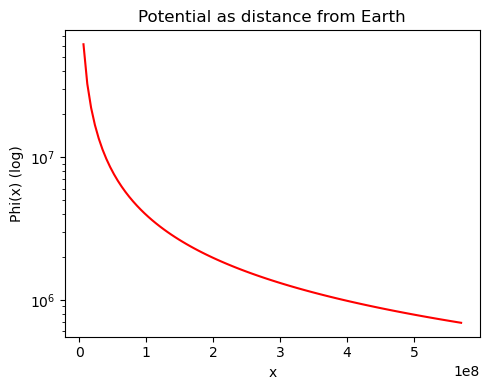

In [4]:
distance = 1.5*d_em
x = np.linspace(R_e,distance,100)
y = 0
x_M = 0
y_M = 0

fig , ax = plt.subplots(figsize=(5,4))
ax.plot(x,np.abs(Phi(M_e,x_M,y_M,x,y)),'r')
ax.set_xlabel("x")
ax.set_yscale('log')
ax.set_ylabel("Phi(x) (log)")
ax.set_title("Potential as distance from Earth")

fig.tight_layout()

3. Then, make a 2D color-mesh plot of the potential $\Phi$ with the Earth at the origin. Plot $|\Phi|$
over a large range of $x$ and $y$, for example, from $-1.5d_{EM}$ to $+1.5d_{EM}$ . Force the plot to have
a square aspect ratio. Make sure to add a nice colorbar, and make the colorbar logarithmic.

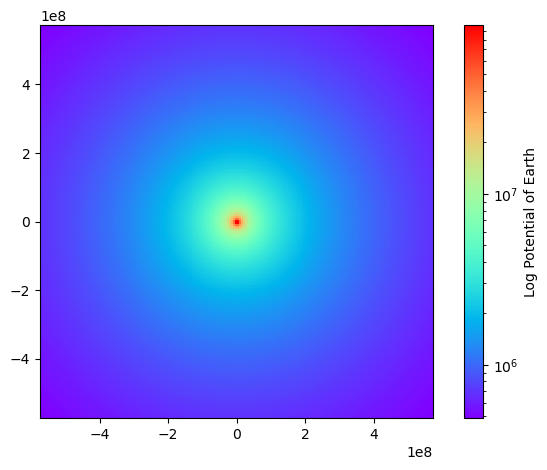

In [5]:
from matplotlib.colors import LogNorm # for log color scale

x = np.linspace(-1.5*d_em, 1.5*d_em, 200)
y = np.linspace(-1.5*d_em, 1.5*d_em, 200)

X,Y = np.meshgrid(x,y)
# print(X.shape, Y.shape)

Z = np.abs(Phi(M_e,x_M,y_M,X,Y))

fig , ax = plt.subplots()
ax.set_aspect('equal')
mesh = ax.pcolormesh(X, Y, Z, cmap='rainbow', norm = LogNorm())

cbar = fig.colorbar(mesh)
cbar.set_label('Log Potential of Earth')

plt.tight_layout()

## Part 2: The Gravitational Potential of the Earth-Moon System
-----

Now, imagine the Earth is at the origin $(x_{E},y_{E}) = (0,0)$, 
and the moon is at a location $(x_{M},y_{M}) = \big( \frac{d_{EM}}{\sqrt{2}}, \frac{d_{EM}}{\sqrt{2}} \big)$.

1. Make an updated 2D color-mesh plot, from $-1.5d_{EM}$ to $+1.5d_{EM}$,
of the gravitational potential of the combined Earth-Moon system.

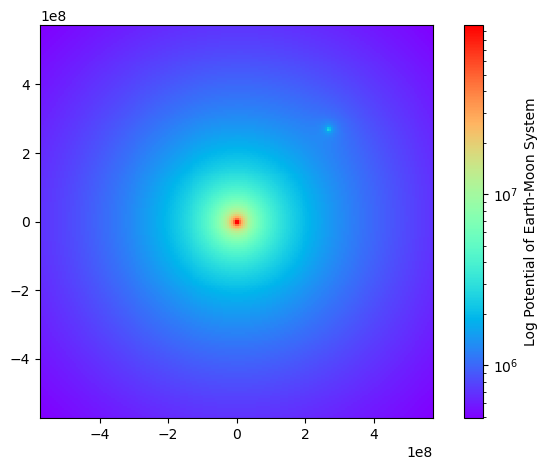

In [6]:
x_E = 0
y_E = 0
x_M = d_em/np.sqrt(2)
y_M = d_em/np.sqrt(2)

Z_total = np.abs(Phi(M_e,x_E,y_E,X,Y)) + np.abs(Phi(M_m,x_M,y_M,X,Y))
fig , ax = plt.subplots()
ax.set_aspect('equal')
mesh = ax.pcolormesh(X, Y, Z_total, cmap='rainbow', norm = LogNorm())

cbar = fig.colorbar(mesh)
cbar.set_label('Log Potential of Earth-Moon System')

plt.tight_layout()

2. Additionally, make a 2D contour plot over the same $x$ and $y$ range.
Do not let all the contours bunch up around the Earth and Moon.
You will probably again need to tell matplotlib to use a logarithmic color scale.

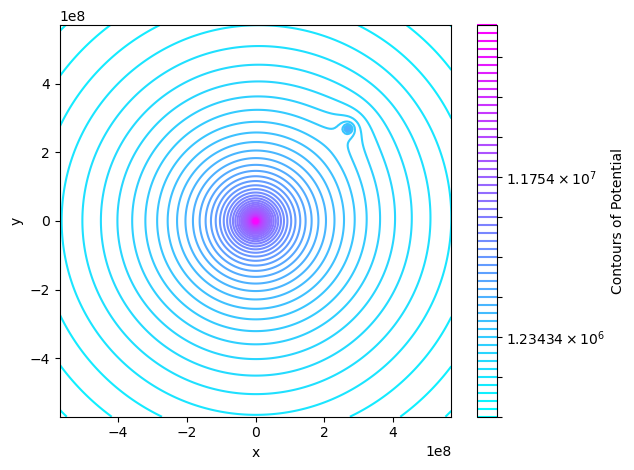

In [7]:
fig , ax = plt.subplots()
custom_levels = np.geomspace(4*10**5,1*10**8,50) 
contour = ax.contour(X, Y, Z_total, cmap='cool', levels = custom_levels, norm = LogNorm())

ax.set_aspect('equal')
ax.set_ylabel("y")
ax.set_xlabel("x")

cbar = fig.colorbar(contour)
cbar.set_label('Contours of Potential')

# print(np.min(Z_total), np.max(Z_total))

plt.tight_layout()

## Part 3: The Gravitational Force Field of the Earth-Moon System
----
The gravitational force $\vec{F}$ 
that a mass $M_1$ exerts on a mass $m_2$ is:

$$\vec{F}_{21} = -G \frac{M_1 m_2}{|\vec{r}_{21}|^2} \hat{r}_{21}$$

where $\vec{r}_{21}$ is the displacement vector from $M_1$ to $m_2$.

1. Code up a function that takes as an input the mass of a body $M_1$, 
the mass of a secondary body $m_2$,
the cartesian location of the first mass $(x_1, y_1)$, 
and the cartesian location of the second body $(x_2, y_2)$. 
Have the function return the two gravitational force components, 
$F_x$ and $F_y$, experienced by the mass $m_2$ 
from the force exerted by $M_1$.
Note that the gravitational force contains a singularity, 
and so if you made the approximation that the Earth is a finite point,
you will need to avoid it.
Like for the 1D potential, make sure it follows modern best-coding practices.

In [8]:
def F(M1,m2,x1,y1,x2,y2 : float) -> tuple:
    '''A function which calculates the components of Gravitational force

    Args:
        M1 (float or int): the mass of the first body
        m2 (float or int): the mass of the secondary body
        x1 (float or int): the x coord of the 1st body
        y1 (float or int): the y coord of the 1st body
        x2 (float or int): the x coord of the 2nd body
        y2 (float or int): the y coord of the 2nd body

    Returns:
        float: the force components of body 1 on body 2.
    '''
    dx = x2 - x1
    dy = y2 - y1
    r = np.sqrt(dx**2 + dy**2)
    if not (isinstance(M1, (int, float, np.ndarray)) and
            isinstance(m2, (int, float, np.ndarray)) and
            isinstance(x1, (int, float, np.ndarray)) and 
            isinstance(y1, (int, float, np.ndarray)) and 
            isinstance(x2, (int, float, np.ndarray)) and 
            isinstance(y2, (int, float, np.ndarray))):
        raise TypeError(f"Input is of the wrong type!")
    elif M1 < 0 or m2 < 0:
        raise ValueError(f"'M1' and 'm2' must be positive")
    else:
        F_x = -G*((M1*m2)/(r**2)*(dx/r))
        F_y = -G*((M1*m2)/(r**2)*(dy/r))
        return F_x, F_y

#try2 = F(10000,10000,1,1,1000,2000)
#print(try2)

2. Assuming the Earth is still at the origin and the Moon is still at 
$(x_M, y_M) = \big( \frac{d_{EM}}{\sqrt{2}}, \frac{d_{EM}}{\sqrt{2}} \big)$, 
make a 2D streamplot of the gravitational force the Earth-Moon system 
will exert on the Apollo 11 command module.
Plot the force over the same x-y range of $-1.5 d_{EM}$ to $+1.5 d_{EM}$.
Add a nice color bar, which will again probably need to be logarithmic.
Mark the location of the earth with a black circle, and the moon with a black square.
Add a legend.

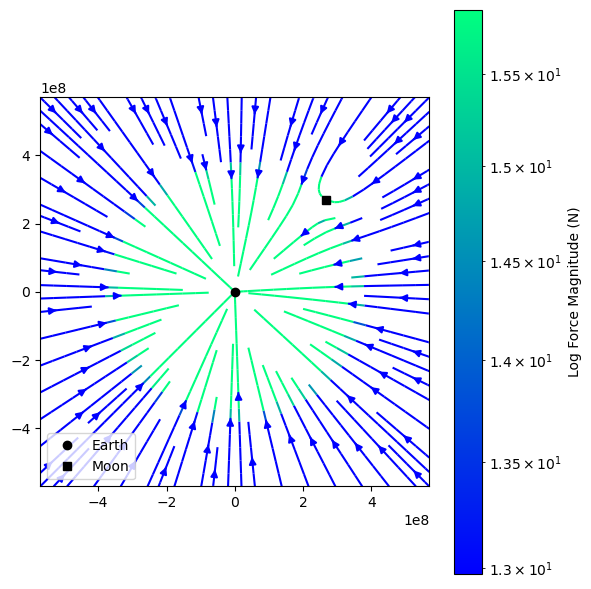

In [9]:
from matplotlib.colors import LogNorm

x = np.linspace(-1.5*d_em, 1.5*d_em, 200)
y = np.linspace(-1.5*d_em, 1.5*d_em, 200)
X, Y = np.meshgrid(x, y)
x_E = 0
y_E = 0
x_M = d_em / np.sqrt(2)
y_M = d_em / np.sqrt(2)

F_x_E, F_y_E = F(M_e, M_a, x_E, y_E, X, Y)
F_x_M, F_y_M = F(M_m, M_a, x_M, y_M, X, Y)
Fx_total = F_x_E + F_x_M
Fy_total = F_y_E + F_y_M
F_mag = np.sqrt(Fx_total**2 + Fy_total**2)

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect('equal')
strm = ax.streamplot(X, Y, Fx_total, Fy_total, color=F_mag, cmap='winter', norm=LogNorm())

cbar = fig.colorbar(strm.lines, ax=ax)
cbar.set_label('Log Force Magnitude (N)')

ax.plot(x_E, y_E, 'ko', label='Earth')
ax.plot(x_M, y_M, 'ks', label='Moon')
ax.legend(loc='lower left')
plt.tight_layout()

3. You will note there is a point between the Earth and the Moon where the field lines seem to vanish. This is the point where the Earth's and Moon's gravitational forces cancel eachother. By setting $|\vec{F}_{moon}| = |\vec{F}_{earth}|$, calculate the radial distance of the "balance point." From there, identify the $x$ and $y$ coordinates of the balance point. Typeset your derivation (show multiple steps!) in latex in a markdown cell below. Then, calculate it numerically, and draw the answer onto a new version of your force field plot. Again mark the location of the earth with a black circle, and the moon with a black square; mark the location of the balance point with a red x. Add a legend.

**Your Derivation Goes in the markdown cell below:**

Equating the gravitational forces and canceling $G$ and $m$:
$$\frac{M_E}{r_E^2} = \frac{M_M}{r_M^2}$$

Substituting $r_M = d_{EM} - r_E$ and taking the square root of both sides:
$$\frac{\sqrt{M_E}}{r_E} = \frac{\sqrt{M_M}}{d_{EM} - r_E}$$

Cross-multiplying and solving for $r_E$:
$$r_E (\sqrt{M_E} + \sqrt{M_M}) = d_{EM} \sqrt{M_E}$$
$$r_E = d_{EM} \frac{\sqrt{M_E}}{\sqrt{M_E} + \sqrt{M_M}}$$

Since the Earth and Moon are along a $45^\circ$ diagonal, the coordinates for the balance point are:
$$x_{bal} = \frac{r_E}{\sqrt{2}}$$
$$y_{bal} = \frac{r_E}{\sqrt{2}}$$

And your updated plot, including the balance point, goes in the cell below.

Distance from Earth: 3.42e+08 m
Distance from Moon: 3.80e+07 m
Percentage of way to the Moon: 90.0%


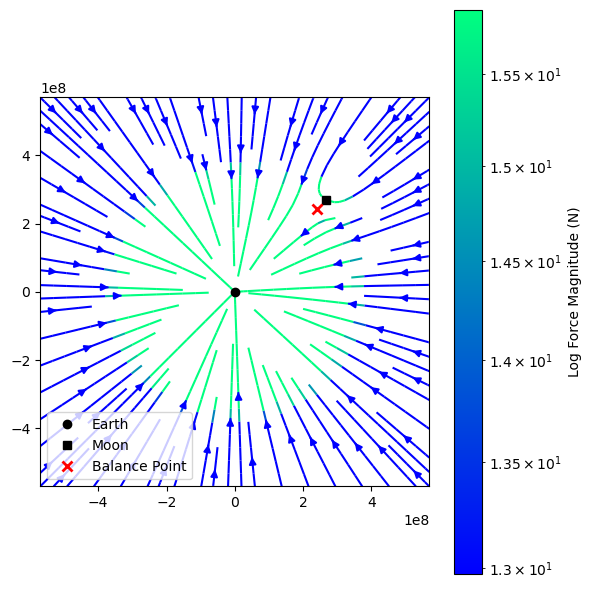

In [10]:
r_E = d_em * np.sqrt(M_e) / (np.sqrt(M_e) + np.sqrt(M_m))
x_bal = r_E / np.sqrt(2)
y_bal = r_E / np.sqrt(2)

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect('equal')

strm = ax.streamplot(X, Y, Fx_total, Fy_total, color=F_mag, cmap='winter', norm=LogNorm())
cbar = fig.colorbar(strm.lines, ax=ax)
cbar.set_label('Log Force Magnitude (N)')

ax.plot(x_E, y_E, 'ko', label='Earth')
ax.plot(x_M, y_M, 'ks', label='Moon')
ax.plot(x_bal, y_bal, 'rx', markersize=7, markeredgewidth=2, label='Balance Point')

ax.legend(loc='lower left')
plt.tight_layout()

# for the quantitative discussion below
print(f"Distance from Earth: {r_E:.2e} m")
print(f"Distance from Moon: {d_em - r_E:.2e} m")
print(f"Percentage of way to the Moon: {(r_E / d_em) * 100:.1f}%")

4. Quantitatively discuss your conclusions. Is the balance point close to the Moon or Earth? How close? Does this make sense?

**Your Answer Goes in the markdown cell below:**

Answer:
The balance point is significantly closer to the Moon, located around 90% of the way along the total distance from the Earth. This does make physical sense. Because the Earth is roughly 81 times more massive than the Moon, its gravitational field is much stronger. Since gravitational force weakens with the square of the distance, you must be much closer to the less massive body (the Moon) for its weaker pull to exactly cancel out the pull from the massive Earth.

## Part 4: Altitude of the Saturn V Rocket
----
Rockets function by conservation of momentum.
The ejection of fuel backwards propels the rocket forwards.
The change in a rocket's velocity $\Delta v$ as a 
function of time $t$ (under a set of simplifying assumptions) 
is given by the Tsiolkovsky rocket equation:

$$\Delta v(t) = v_e \ln \left(\frac{m_0}{m(t)}\right) - gt$$

where $m_0$ is the initial "wet" mass (fuel + rocket parts + payload), 
$m(t) = m_0 - \dot{m}t$ is the mass at time $t$, 
$\dot{m}$ is the fuel burn rate (which we will assume to be constant), 
$v_e$ is the fuel exhaust velocity, and $g$ is the gravitational acceleration.

You can find the altitude $h$ of the rocket at "burnout" 
(when all the fuel is used up) by integrating the velocity over time:

$$h = \int_{0}^{T} \Delta v(t) \, dt$$

where $T$ is the total burn time of the rocket, 
which by conservation of momentum arguments is:

$$T = \frac{m_0 - m_f}{\dot{m}}$$

where $m_f$ is the final "dry mass" of the rocket, 
once all the fuel is burned.

1. Calculate the burn time $T$ for the first stage of
the new Saturn V rocket that NASA is planning
to use to carry the Apollo capsule.

In [11]:
# for later
import scipy.integrate as integrate

T = (m_0 - m_f) / m_dot
print(f"Calculated Burn Time (T): {T:.2f} seconds")

Calculated Burn Time (T): 157.69 seconds


2. Define a function that returns the change in velocity $\Delta v(t)$.
It should take all necessary arguments, meaning: the time, 
wet mass, dry mass, burn rate, exhaust speed, and gravitational constant $g$. 
Have it return the change in velocity.
Note that the rocket eventually runs out of fuel, 
so you should design your function carefully so that 
$\Delta v$ eventually becomes zero after all fuel is spent.
Again, document and guard your function according to best practices.

In [12]:
def delta_v(t: float, m_0: float, m_f: float, m_dot: float, v_e: float, g: float = 9.81) -> float:
    '''Calculates the change in velocity of a rocket over time.

    Args:
        t (float): time in seconds
        m_0 (float): initial wet mass
        m_f (float): final dry mass
        m_dot (float): fuel burn rate
        v_e (float): exhaust velocity
        g (float): gravitational acceleration

    Returns:
        float: change in velocity, or 0 if out of fuel
    '''
    if not (isinstance(t, (int, float)) and isinstance(m_0, (int, float)) and 
            isinstance(m_f, (int, float)) and isinstance(m_dot, (int, float)) and 
            isinstance(v_e, (int, float)) and isinstance(g, (int, float))):
        raise TypeError("All inputs must be numeric!")
    
    if t < 0:
        raise ValueError("Time cannot be negative")
        
    T_max = (m_0 - m_f) / m_dot
    
    # Delta_v becomes zero after all fuel is spent
    if t > T_max:
        return 0.0  
        
    m_t = m_0 - m_dot * t
    return v_e * np.log(m_0 / m_t) - (g * t)

3. Compute the altitude of the rocket at the end of the burn.
Do this by numerically integrating from $t=0$ (launch) to $t=T$ (burnout).
Use the `scipy.integrate.quad()` function.

In [13]:
h, error = integrate.quad(delta_v, 0, T, args=(m_0, m_f, m_dot, v_e, g))

print(f"Calculated Altitude at burnout (h): {h / 1000:.2f} km")

Calculated Altitude at burnout (h): 74.09 km


4. Just last week, NASA got the test results back from the first prototype
of Saturn V. They found that it burned for about 160 seconds
and lifted the system to an altitude of about 70km.
Director Kranz has asked you to compare your calculations for 
$T$ and $h$ to the testing data.
You should offer some explanations about why your calculation
is an over or under estimate, e.g. neglecting drag.

**Your Answer Goes in the markdown cell below:**

***ANSWER***

**Comparison to NASA Test Data:**

Our calculated burn time ($T \approx 157.7$ s) is an excellent match for NASA's test data (160 s). Our calculated altitude ($h \approx 74.1$ km) is also remarkably close to the test data of 70 km, but slightly overestimates the true altitude. This overestimate is due to a few simplifying assumptions in our mathematical model:

1. **Neglecting Aerodynamic Drag:** The rocket equation assumes the rocket is traveling in a vacuum. Launching from Earth requires pushing through a dense lower atmosphere. Drag forces oppose the rocket's motion, sapping kinetic energy and reducing the final altitude.
2. **Flight Trajectory:** We integrated the velocity assuming the rocket flew perfectly straight up for the entire burn. In reality, rockets perform a "gravity turn" shortly after launch, pitching horizontally to build up the massive orbital velocity required to stay in space. Therefore, some of the rocket's energy goes into horizontal distance rather than purely vertical altitude.